In [2]:
import nibabel as nb
import os
import numpy as np
import matplotlib.pyplot as plt
import globals as gl
import nitools as nt
import surfAnalysisPy as surf
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap,rgb_to_hsv, hsv_to_rgb
import pickle
from pcm_cortical import find_model
from sklearn.preprocessing import MinMaxScaler

import pyvista as pv

# Define the updated function and test it on the provided file
def load_border_vertices_xml(filepath):
    vertices = []
    inside_vertices_block = False
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if "<Vertices>" in line:
                inside_vertices_block = True
                line = line.replace("<Vertices>", "")
            if inside_vertices_block:
                if "</Vertices>" in line:
                    line = line.replace("</Vertices>", "")
                    inside_vertices_block = False
                if line:
                    numbers = [int(x) for x in line.split()]
                    vertices.extend(numbers)
    return np.array(vertices)


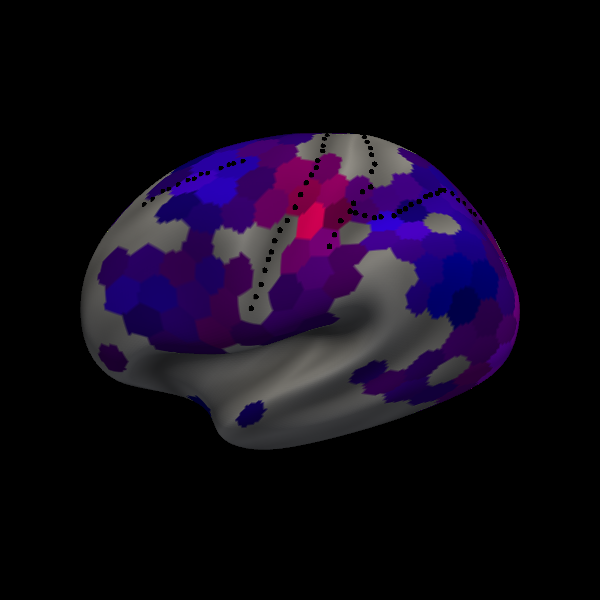

In [3]:
glm = 12
ntessels = 362
experiment = 'smp2'

Hem = ['L',]

mclip = .7
threshold = .3 / mclip

p = pv.Plotter(window_size=(600, 600))

scaler = MinMaxScaler()

column_names = ['cue', 'uncertainty']

cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.pcmDir,
                            f'theta_component.Icosahedron{ntessels}.glm{glm}.pcm.plan.dscalar.nii'))
giftis = nt.split_cifti_to_giftis(cifti, 'func', column_names=column_names)

for h, H in enumerate(Hem):
    data = nt.get_gifti_data_matrix(giftis[h])

    idx_cue = column_names.index('cue')
    idx_cert = column_names.index('uncertainty')

    surf = nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.{H}.very_inflated.surf.gii')
    coords = surf.darrays[0].data
    faces = surf.darrays[1].data.astype(np.uint32)
    faces = np.hstack([np.full((faces.shape[0], 1), 3), faces]).astype(np.int32).flatten()

    sulc = nt.get_gifti_data_matrix(nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii'))
    if H=='L':
        sulc = sulc[:len(data)]
    else:
        sulc = sulc[len(data):]

    border_verts = load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-IPS.border")
    borderIPS = coords[border_verts]

    border_verts = load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-CS.border")
    borderCS = coords[border_verts]

    border_verts = load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-PoCS.border")
    borderPoCS = coords[border_verts]

    border_verts = load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-SF.border")
    borderSF = coords[border_verts]

    data = np.sqrt(np.exp(data))
    data = scaler.fit_transform(data)
    data = np.clip(data / mclip, 0, 1)

    sulc_norm = MinMaxScaler((0.3, 0.7)).fit_transform(sulc.reshape(-1, 1)).flatten()

    rgba = np.zeros((len(sulc_norm), 4))
    rgba[:, 0] = sulc_norm  # red = grey
    rgba[:, 1] = sulc_norm  # green = grey
    rgba[:, 2] = sulc_norm  # blue = grey
    rgba[:, 3] = 1.0        # opaque background

    overlay_mask = (data[:, 0] >= threshold) | (data[:, 1] >= threshold)

    rgba[overlay_mask, 0] = data[overlay_mask, 0]  # red
    rgba[overlay_mask, 1] = 0                    # green stays off for 2-color blend
    rgba[overlay_mask, 2] = data[overlay_mask, 1]  # blue
    rgba[overlay_mask, 3] = 1.0                     # alpha: opaque overlay
    rgba[~overlay_mask, 3] = 1.0                    # still show grey background

    mesh = pv.PolyData(coords, faces)
    mesh.point_data['rgb'] = rgba

    p.add_mesh(mesh, scalars='rgb', rgb=True, lighting=True, show_scalar_bar=False,)
    p.add_points(borderCS[::3], color='k', point_size=6, render_points_as_spheres=True)
    p.add_points(borderPoCS[::3], color='k', point_size=6, render_points_as_spheres=True)
    p.add_points(borderIPS[::3], color='k', point_size=6, render_points_as_spheres=True)
    p.add_points(borderSF[::3], color='k', point_size=6, render_points_as_spheres=True)

p.set_background('black')
p.view_vector((0, -1, 5))  # dorsal view
p.view_vector((-1, 0, .5))  # lateral view
p.show()


In [4]:
# === Define parameters ===
glm = 12
ntessels = 362
experiment = 'smp2'
Hem = ['L',]
mclip = .7
threshold = .1 #.3 / mclip
column_names = ['finger', 'interaction1', 'interaction2', 'cue', 'uncertainty', 'surprise']

# === Define custom colormap (white to gold) ===
cmap = LinearSegmentedColormap.from_list("cmap", ["white", "#D4AF37"])

# === Start plotting ===
p = pv.Plotter(window_size=(600, 600))
scaler = MinMaxScaler()

# === Load data ===
cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.pcmDir,
                            f'theta_feature.Icosahedron{ntessels}.glm{glm}.pcm.exec.dscalar.nii'))
giftis = nt.split_cifti_to_giftis(cifti, 'func', column_names=column_names)

for h, H in enumerate(Hem):
    data = nt.get_gifti_data_matrix(giftis[h])

    # Load surface
    surf = nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.{H}.very_inflated.surf.gii')
    coords = surf.darrays[0].data
    faces = surf.darrays[1].data.astype(np.uint32)
    faces = np.hstack([np.full((faces.shape[0], 1), 3), faces]).astype(np.int32).flatten()

    # Load sulcal map
    sulc = nt.get_gifti_data_matrix(nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii'))
    sulc = sulc[:len(data)] if H == 'L' else sulc[len(data):]

    # Load borders
    borderIPS = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-IPS.border")]
    borderCS = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-CS.border")]
    borderPoCS = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-PoCS.border")]
    borderSF = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-SF.border")]

    data2 = data ** 2
    data = np.vstack([
        data2[:, 0] + data2[:, 1],
        data[:, 1] * data[:, 2],
        data2[:, 2] + data2[:, 3],
        data2[:, 4],
        data2[:, 5]
    ]).T

    # Plot surface
    mesh = pv.PolyData(coords, faces)
    mesh.point_data["overlay"] = data[:, 0]
    p.add_mesh(mesh, scalars="overlay", cmap=cmap, clim=[0., .5], lighting=True, show_scalar_bar=False)
    p.add_scalar_bar(title="Weight",
                 n_labels=3,                 # Show fewer ticks
                 vertical=False,            # Horizontal layout
                 color='w',
                 shadow=True,
                 position_x=0.3,  # Centered horizontally (0 = left, 1 = right)
                 position_y=0.05, # Lower position (closer to bottom of figure)
                 width=0.4,       # Proportion of figure width
                 height=0.04)

    # Plot borders
    for border in [borderCS, borderPoCS, borderIPS, borderSF]:
        p.add_points(border[::3], color='k', point_size=6, render_points_as_spheres=True)

# Final touches
p.set_background('black')
p.view_vector((-1, 0, .5))  # lateral view
p.show()

IndexError: index 5 is out of bounds for axis 1 with size 5

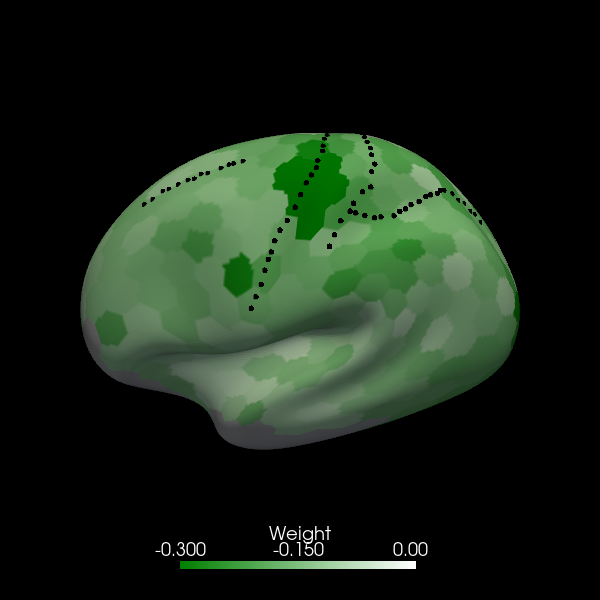

In [61]:
# === Define parameters ===
glm = 12
ntessels = 362
experiment = 'smp2'
Hem = ['L',]
mclip = .7
threshold = .1 #.3 / mclip
column_names = ['finger', 'interaction1', 'interaction2', 'cue', 'uncertainty', 'surprise']

# === Define custom colormap (white to gold) ===
cmap = LinearSegmentedColormap.from_list("cmap", ["green", "white", ])

# === Start plotting ===
p = pv.Plotter(window_size=(600, 600))
scaler = MinMaxScaler()

# === Load data ===
cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.pcmDir,
                            f'theta_feature.Icosahedron{ntessels}.glm{glm}.pcm.exec.dscalar.nii'))
giftis = nt.split_cifti_to_giftis(cifti, 'func', column_names=column_names)

for h, H in enumerate(Hem):
    data = nt.get_gifti_data_matrix(giftis[h])

    # Load surface
    surf = nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.{H}.very_inflated.surf.gii')
    coords = surf.darrays[0].data
    faces = surf.darrays[1].data.astype(np.uint32)
    faces = np.hstack([np.full((faces.shape[0], 1), 3), faces]).astype(np.int32).flatten()

    # Load sulcal map
    sulc = nt.get_gifti_data_matrix(nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii'))
    sulc = sulc[:len(data)] if H == 'L' else sulc[len(data):]

    # Load borders
    borderIPS = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-IPS.border")]
    borderCS = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-CS.border")]
    borderPoCS = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-PoCS.border")]
    borderSF = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-SF.border")]

    data2 = data ** 2
    data = np.vstack([
        data2[:, 0] + data2[:, 1],
        data[:, 1] * data[:, 2],
        data2[:, 2] + data2[:, 3],
        data2[:, 4],
        data2[:, 5]
    ]).T

    # Plot surface
    mesh = pv.PolyData(coords, faces)
    mesh.point_data["overlay"] = data[:, 1]
    p.add_mesh(mesh, scalars="overlay", cmap=cmap, clim=[-.3, 0], lighting=True, show_scalar_bar=False)
    p.add_scalar_bar(title="Weight",
                 n_labels=3,                 # Show fewer ticks
                 vertical=False,            # Horizontal layout
                 color='w',
                 shadow=True,
                 position_x=0.3,  # Centered horizontally (0 = left, 1 = right)
                 position_y=0.05, # Lower position (closer to bottom of figure)
                 width=0.4,       # Proportion of figure width
                 height=0.04)

    # Plot borders
    for border in [borderCS, borderPoCS, borderIPS, borderSF]:
        p.add_points(border[::3], color='k', point_size=6, render_points_as_spheres=True)

# Final touches
p.set_background('black')
p.view_vector((-1, 0, .5))  # lateral view
p.show()

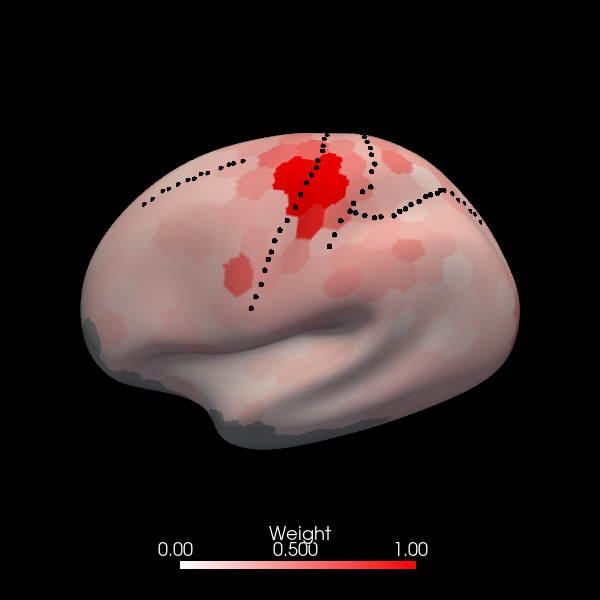

In [38]:
# === Define parameters ===
glm = 12
ntessels = 362
experiment = 'smp2'
Hem = ['L',]
mclip = .7
threshold = .1 #.3 / mclip
column_names = ['finger', 'interaction1', 'interaction2', 'cue', 'uncertainty', 'surprise']

# === Define custom colormap (white to gold) ===
cmap = LinearSegmentedColormap.from_list("cmap", [ "white","red", ])

# === Start plotting ===
p = pv.Plotter(window_size=(600, 600))
scaler = MinMaxScaler()

# === Load data ===
cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.pcmDir,
                            f'theta_feature.Icosahedron{ntessels}.glm{glm}.pcm.exec.dscalar.nii'))
giftis = nt.split_cifti_to_giftis(cifti, 'func', column_names=column_names)

for h, H in enumerate(Hem):
    data = nt.get_gifti_data_matrix(giftis[h])

    # Load surface
    surf = nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.{H}.very_inflated.surf.gii')
    coords = surf.darrays[0].data
    faces = surf.darrays[1].data.astype(np.uint32)
    faces = np.hstack([np.full((faces.shape[0], 1), 3), faces]).astype(np.int32).flatten()

    # Load sulcal map
    sulc = nt.get_gifti_data_matrix(nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii'))
    sulc = sulc[:len(data)] if H == 'L' else sulc[len(data):]

    # Load borders
    borderIPS = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-IPS.border")]
    borderCS = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-CS.border")]
    borderPoCS = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-PoCS.border")]
    borderSF = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-SF.border")]

    data2 = data ** 2
    data = np.vstack([
        data2[:, 0] + data2[:, 1],
        data[:, 1] * data[:, 2],
        data2[:, 2] + data2[:, 3],
        data2[:, 4],
        data2[:, 5]
    ]).T

    # Plot surface
    mesh = pv.PolyData(coords, faces)
    mesh.point_data["overlay"] = data[:, 2]
    p.add_mesh(mesh, scalars="overlay", cmap=cmap, clim=[ 0, 1], lighting=True, show_scalar_bar=False)
    p.add_scalar_bar(title="Weight",
                 n_labels=3,                 # Show fewer ticks
                 vertical=False,            # Horizontal layout
                 color='w',
                 shadow=True,
                 position_x=0.3,  # Centered horizontally (0 = left, 1 = right)
                 position_y=0.05, # Lower position (closer to bottom of figure)
                 width=0.4,       # Proportion of figure width
                 height=0.04)

    # Plot borders
    for border in [borderCS, borderPoCS, borderIPS, borderSF]:
        p.add_points(border[::3], color='k', point_size=6, render_points_as_spheres=True)

# Final touches
p.set_background('black')
p.view_vector((-1, 0, .5))  # lateral view
p.show()

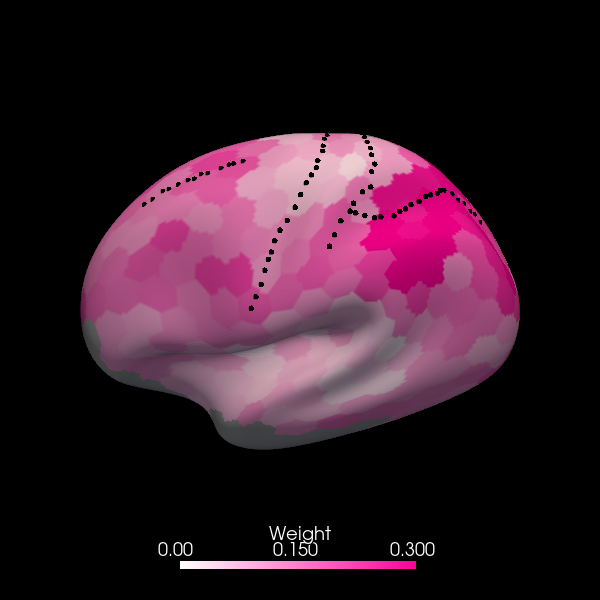

In [60]:
# === Define parameters ===
glm = 12
ntessels = 362
experiment = 'smp2'
Hem = ['L',]
mclip = .7
threshold = .1 #.3 / mclip
column_names = ['finger', 'interaction1', 'interaction2', 'cue', 'uncertainty', 'surprise']

# === Define custom colormap (white to gold) ===
cmap = LinearSegmentedColormap.from_list("cmap", [ "white","#FF0099", ])

# === Start plotting ===
p = pv.Plotter(window_size=(600, 600))
scaler = MinMaxScaler()

# === Load data ===
cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.pcmDir,
                            f'theta_feature.Icosahedron{ntessels}.glm{glm}.pcm.exec.dscalar.nii'))
giftis = nt.split_cifti_to_giftis(cifti, 'func', column_names=column_names)

for h, H in enumerate(Hem):
    data = nt.get_gifti_data_matrix(giftis[h])

    # Load surface
    surf = nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.{H}.very_inflated.surf.gii')
    coords = surf.darrays[0].data
    faces = surf.darrays[1].data.astype(np.uint32)
    faces = np.hstack([np.full((faces.shape[0], 1), 3), faces]).astype(np.int32).flatten()

    # Load sulcal map
    sulc = nt.get_gifti_data_matrix(nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii'))
    sulc = sulc[:len(data)] if H == 'L' else sulc[len(data):]

    # Load borders
    borderIPS = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-IPS.border")]
    borderCS = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-CS.border")]
    borderPoCS = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-PoCS.border")]
    borderSF = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-SF.border")]

    data2 = data ** 2
    data = np.vstack([
        data2[:, 0] + data2[:, 1],
        data[:, 1] * data[:, 2],
        data2[:, 2] + data2[:, 3],
        data2[:, 4],
        data2[:, 5]
    ]).T

    # Plot surface
    mesh = pv.PolyData(coords, faces)
    mesh.point_data["overlay"] = data[:, -1]
    p.add_mesh(mesh, scalars="overlay", cmap=cmap, clim=[ 0, .3], lighting=True, show_scalar_bar=False)
    p.add_scalar_bar(title="Weight",
                 n_labels=3,                 # Show fewer ticks
                 vertical=False,            # Horizontal layout
                 color='w',
                 shadow=True,
                 position_x=0.3,  # Centered horizontally (0 = left, 1 = right)
                 position_y=0.05, # Lower position (closer to bottom of figure)
                 width=0.4,       # Proportion of figure width
                 height=0.04)

    # Plot borders
    for border in [borderCS, borderPoCS, borderIPS, borderSF]:
        p.add_points(border[::3], color='k', point_size=6, render_points_as_spheres=True)

# Final touches
p.set_background('black')
p.view_vector((-1, 0, .5))  # lateral view
p.show()

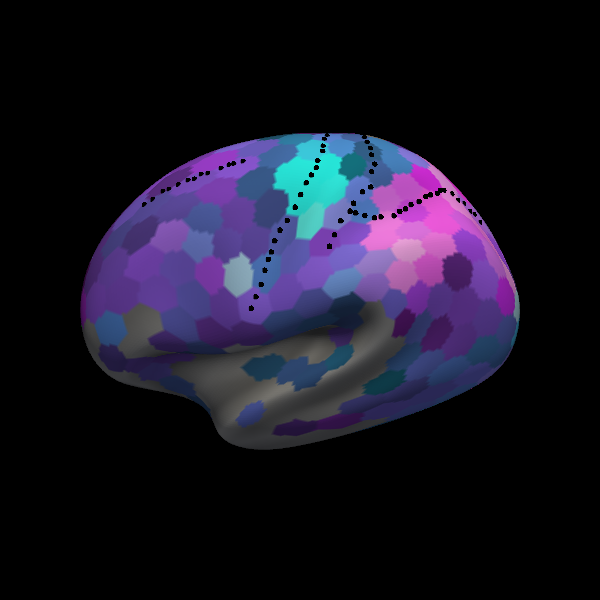

In [68]:
# === Define parameters ===
glm = 12
ntessels = 362
experiment = 'smp2'
Hem = ['L',]
mclip = .7
threshold = .3 #.3 / mclip
column_names = ['finger', 'interaction1', 'interaction2', 'cue', 'uncertainty', 'surprise']

# === Define custom colormap (white to gold) ===
cmap = LinearSegmentedColormap.from_list("cmap", ["white", "#D4AF37"])

# === Start plotting ===
p = pv.Plotter(window_size=(600, 600))
scaler = MinMaxScaler()

# === Load data ===
cifti = nb.load(os.path.join(gl.baseDir, experiment, gl.pcmDir,
                            f'theta_feature.Icosahedron{ntessels}.glm{glm}.pcm.exec.dscalar.nii'))
giftis = nt.split_cifti_to_giftis(cifti, 'func', column_names=column_names)

for h, H in enumerate(Hem):
    data = nt.get_gifti_data_matrix(giftis[h])

    # Load surface
    surf = nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.{H}.very_inflated.surf.gii')
    coords = surf.darrays[0].data
    faces = surf.darrays[1].data.astype(np.uint32)
    faces = np.hstack([np.full((faces.shape[0], 1), 3), faces]).astype(np.int32).flatten()

    # Load sulcal map
    sulc = nt.get_gifti_data_matrix(nb.load(f'/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.LR.sulc.dscalar.gii'))
    sulc = sulc[:len(data)] if H == 'L' else sulc[len(data):]

    # Load borders
    borderIPS = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-IPS.border")]
    borderCS = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-CS.border")]
    borderPoCS = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-PoCS.border")]
    borderSF = coords[load_border_vertices_xml("/cifs/diedrichsen/data/Atlas_templates/fs_LR_32/fs_LR.32k.L.border-SF.border")]

    data2 = data ** 2
    data = np.vstack([
        data2[:, 0] + data2[:, 1],
        np.abs(data[:, 1] * data[:, 2]),
        data2[:, 2] + data2[:, 3],
        data2[:, 4],
        data2[:, 5]
    ]).T

    data = scaler.fit_transform(data)
    data = np.clip(data / mclip, 0, 1)

    rgba = np.zeros((len(sulc_norm), 4))
    rgba[:, 0] = sulc_norm  # red = grey
    rgba[:, 1] = sulc_norm  # green = grey
    rgba[:, 2] = sulc_norm  # blue = grey
    rgba[:, 3] = 1.0        # opaque background

    overlay_mask = (data[:, 1] >= threshold) | (data[:, -1] >= threshold)

    rgba[overlay_mask, 0] = data[overlay_mask, -1]                     # red → magenta
    rgba[overlay_mask, 1] = np.abs(data[overlay_mask, 1])              # green → cyan
    rgba[overlay_mask, 2] = data[overlay_mask, -1] + np.abs(data[overlay_mask, 1])  # blue → both magenta & cyan have blue
    rgba[overlay_mask, 2] = np.clip(rgba[overlay_mask, 2], 0, 1)
    rgba[overlay_mask, 3] = 1.0                     # alpha: opaque overlay
    rgba[~overlay_mask, 3] = 1.0                    # still show grey background

    mesh = pv.PolyData(coords, faces)
    mesh.point_data['rgb'] = rgba

    p.add_mesh(mesh, scalars='rgb', rgb=True, lighting=True, show_scalar_bar=False,)

    # Plot borders
    for border in [borderCS, borderPoCS, borderIPS, borderSF]:
        p.add_points(border[::3], color='k', point_size=6, render_points_as_spheres=True)

# Final touches
p.set_background('black')
p.view_vector((-1, 0, .5))  # lateral view
p.show()